Found 9 chromosomes with PDF files
Creating figure for Locus 1 (NW_022145594.11)...
Creating figure for Locus 2 (NW_022145594.1)...
Creating figure for Locus 3 (NW_022145597.1)...
Creating figure for Locus 4 (NW_022145600.1)...
Creating figure for Locus 5 (NW_022145601.1)...
Creating figure for Locus 6 (NW_022145603.1)...
Creating figure for Locus 7 (NW_022145606.1)...
Creating figure for Locus 8 (NW_022145609.1)...
Creating figure for Locus 9 (NW_022145610.1)...
Created 9 figures
Displaying plots...


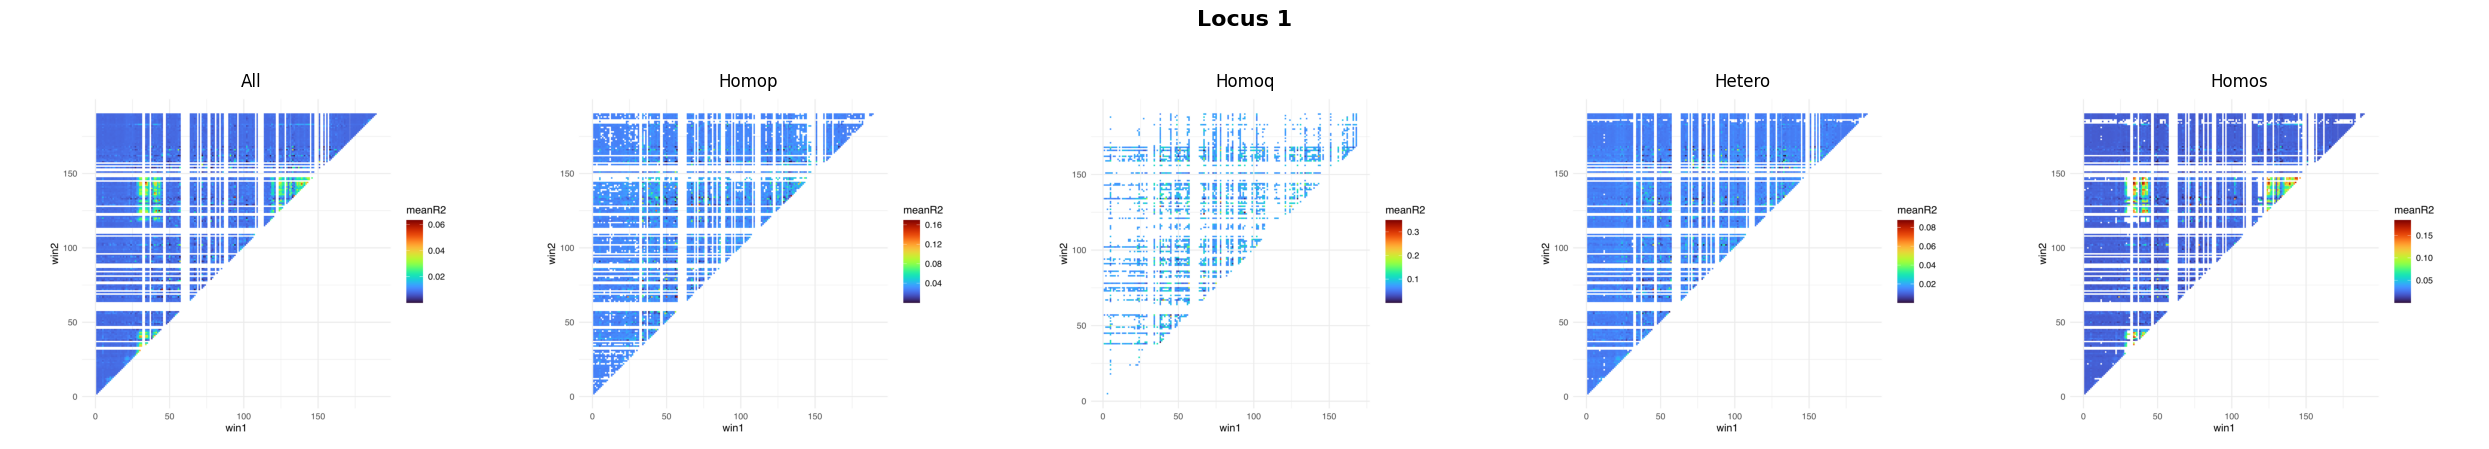

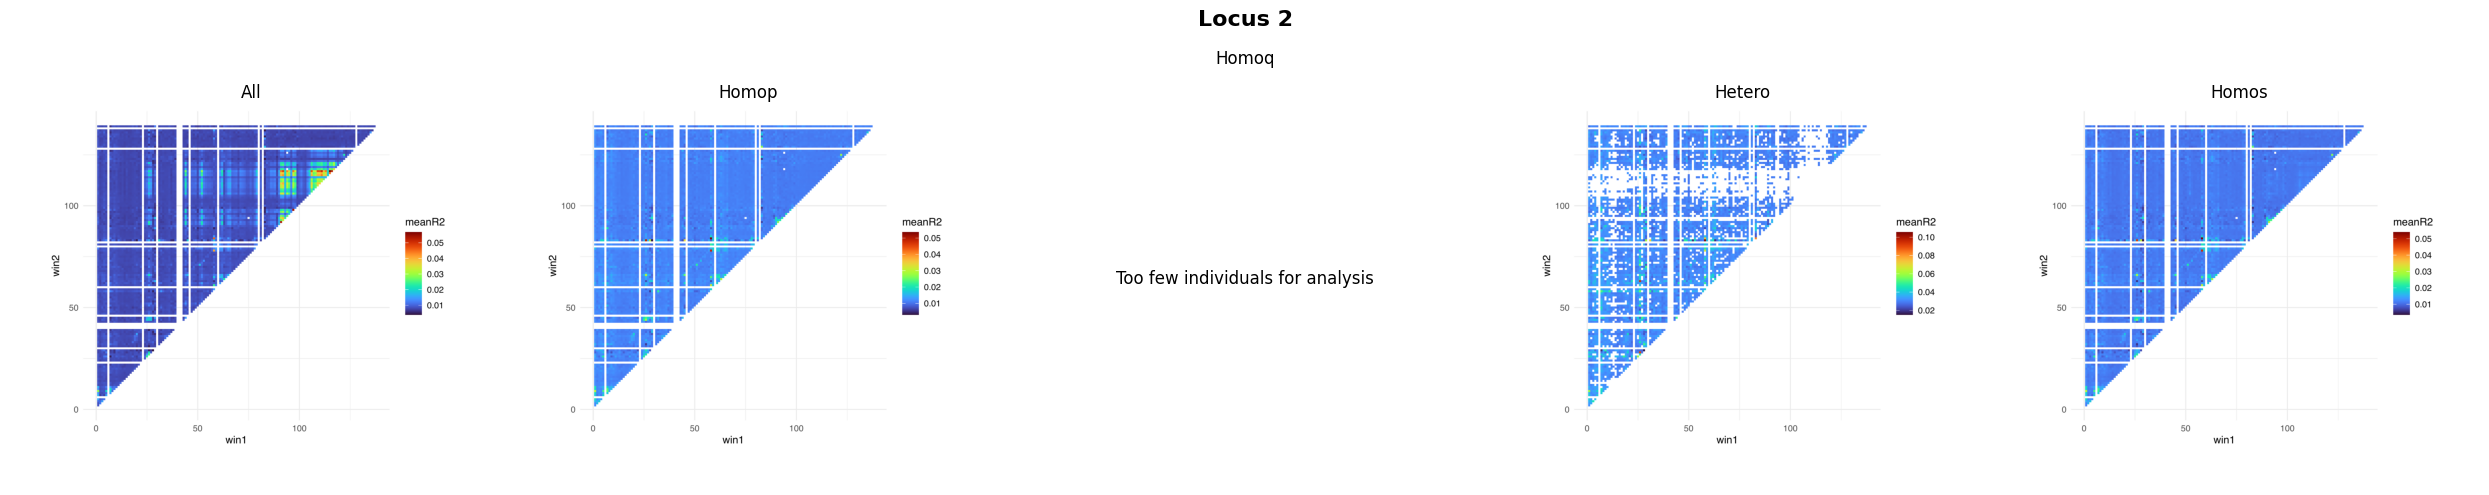

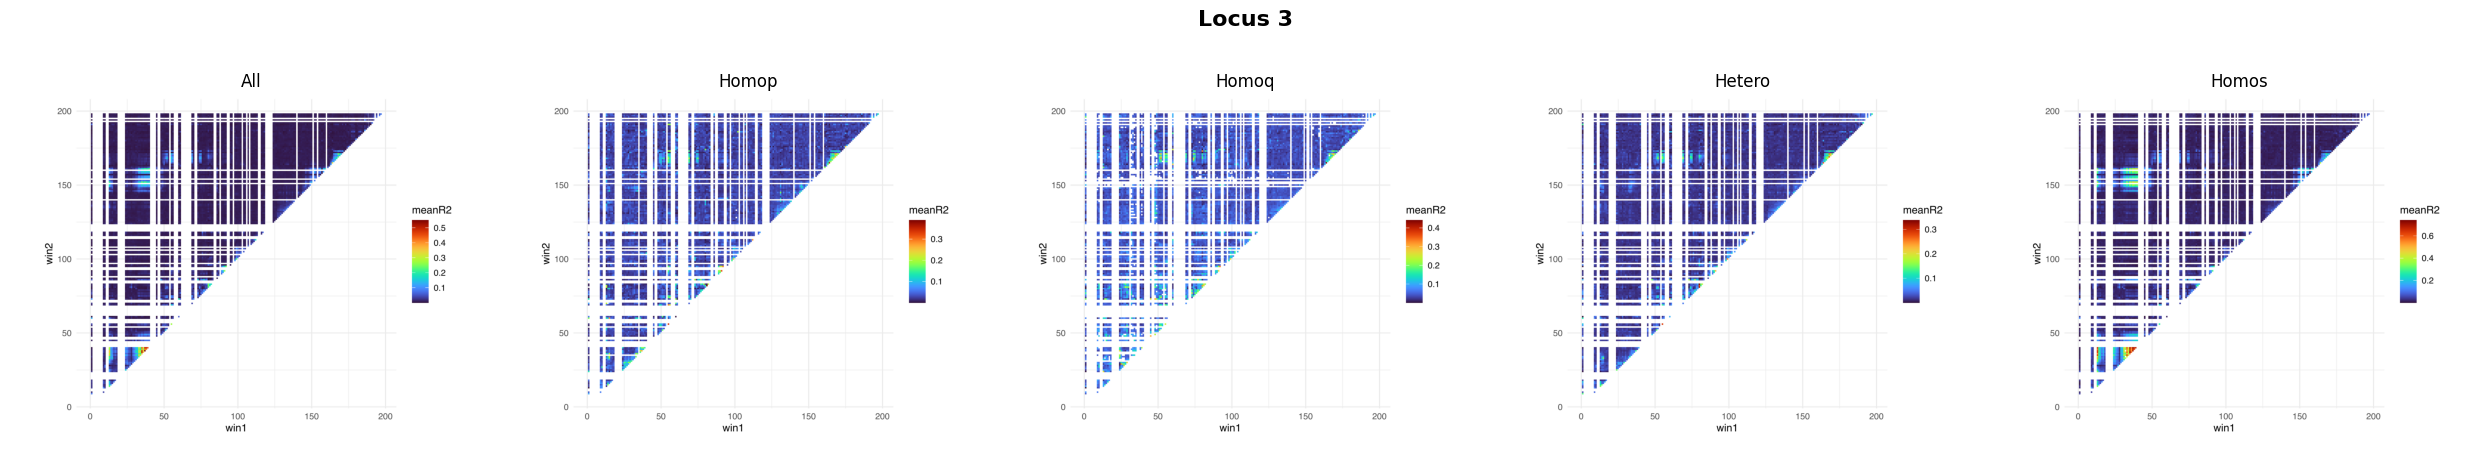

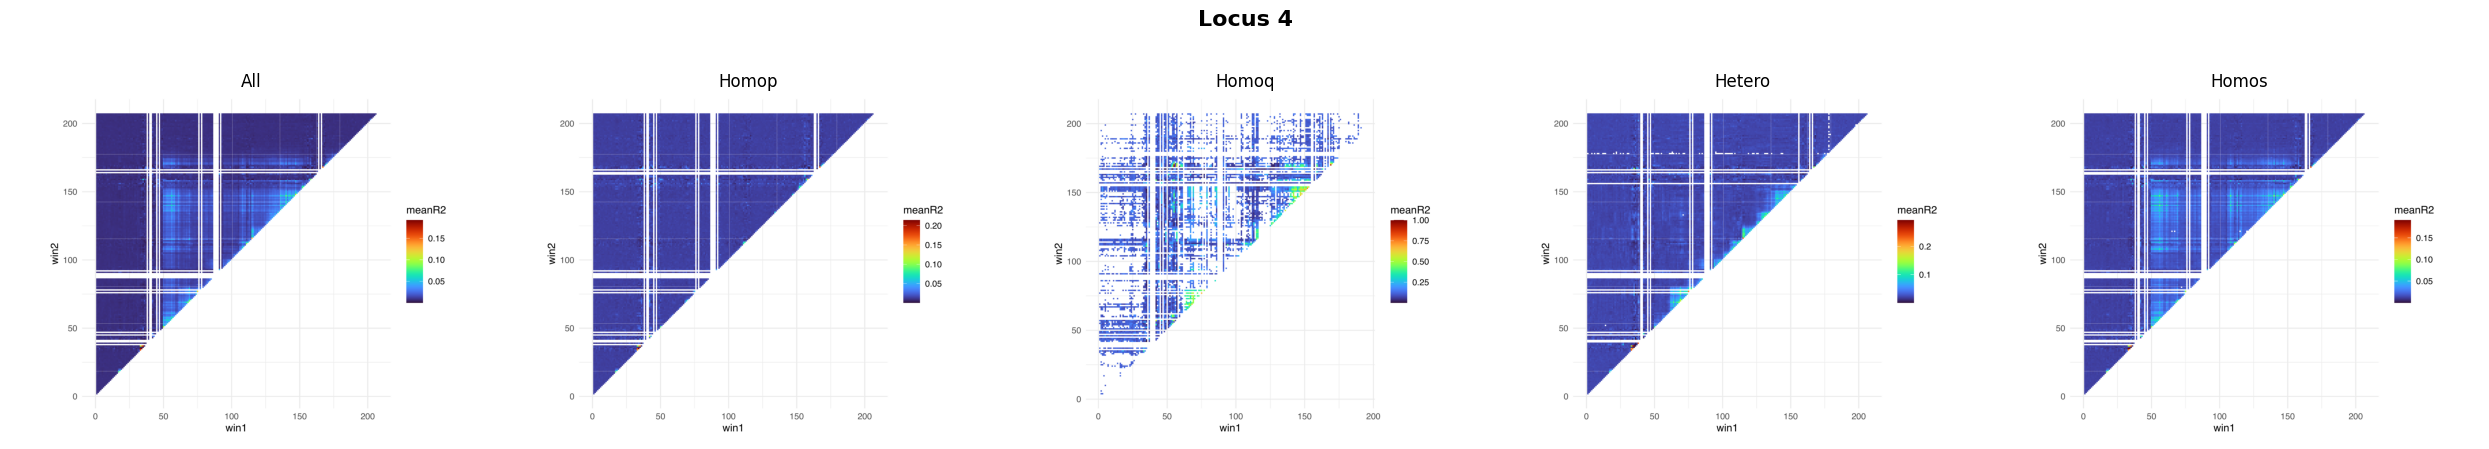

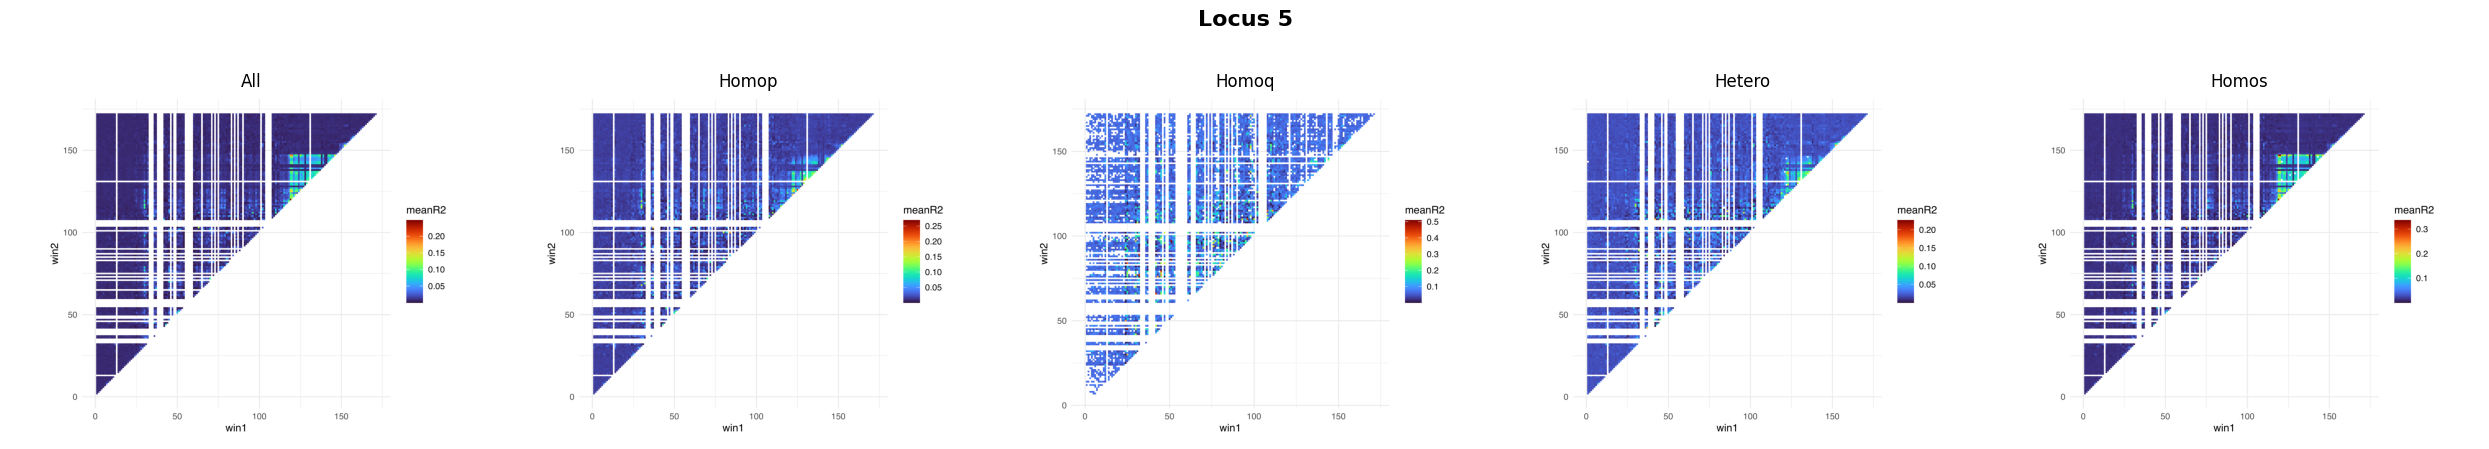

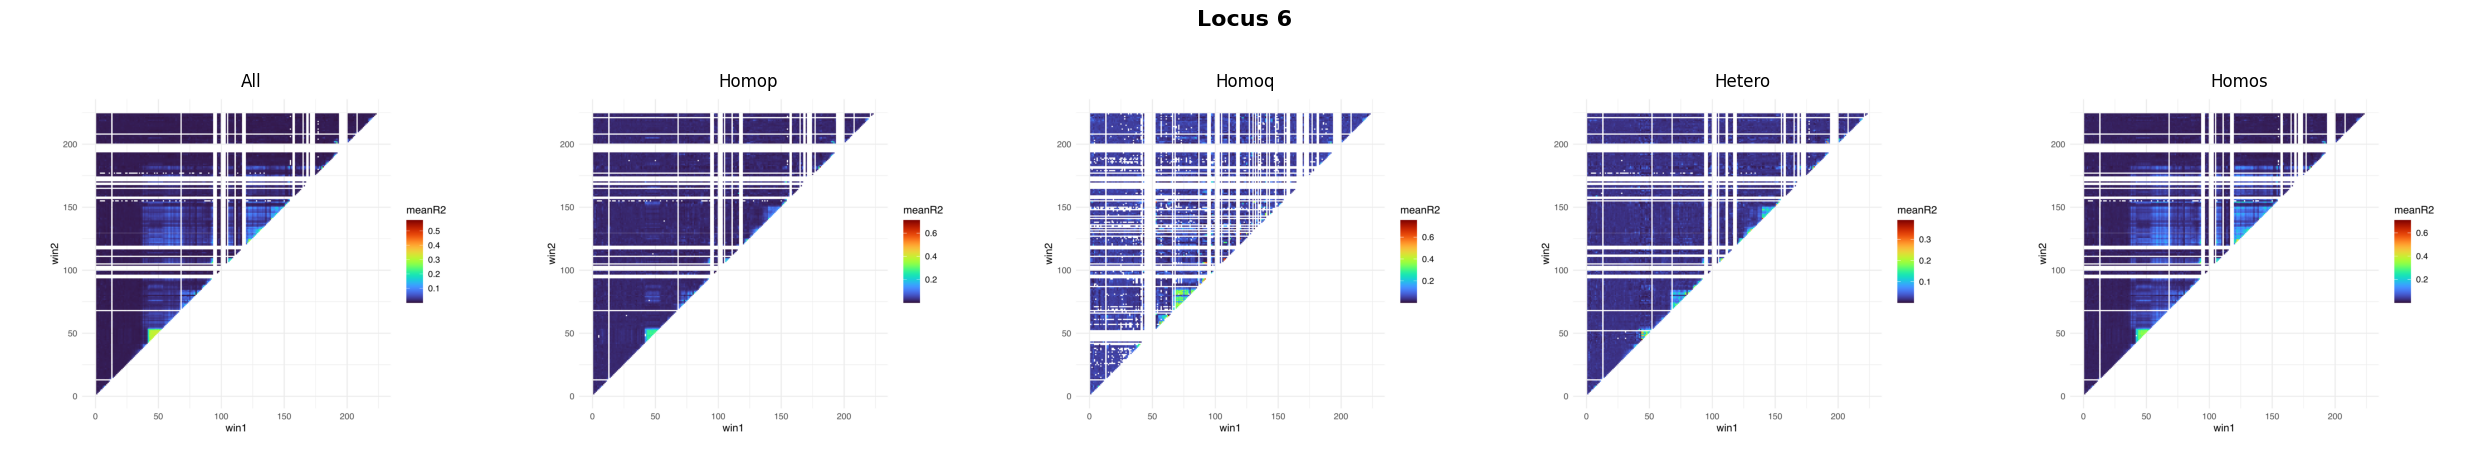

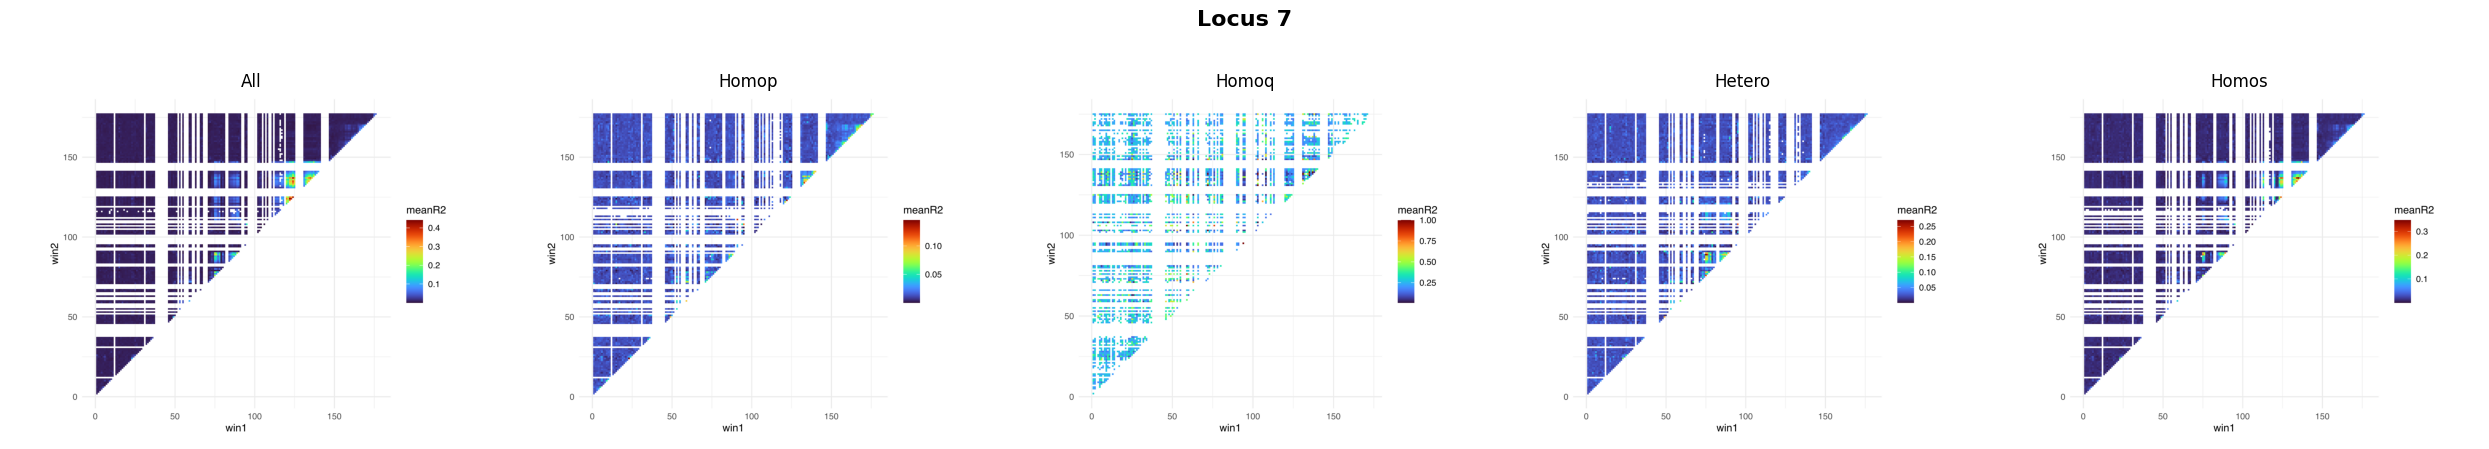

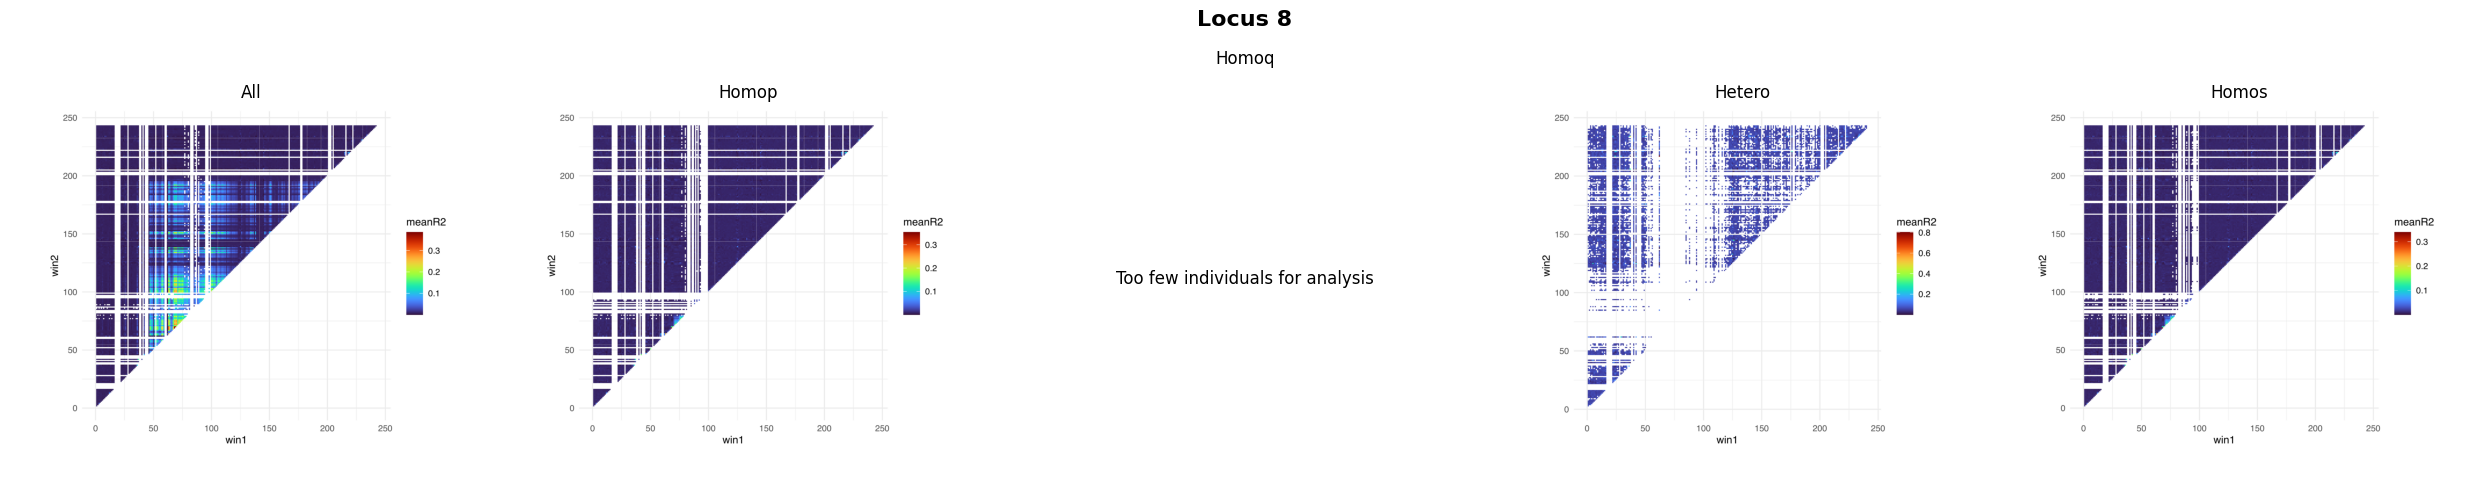

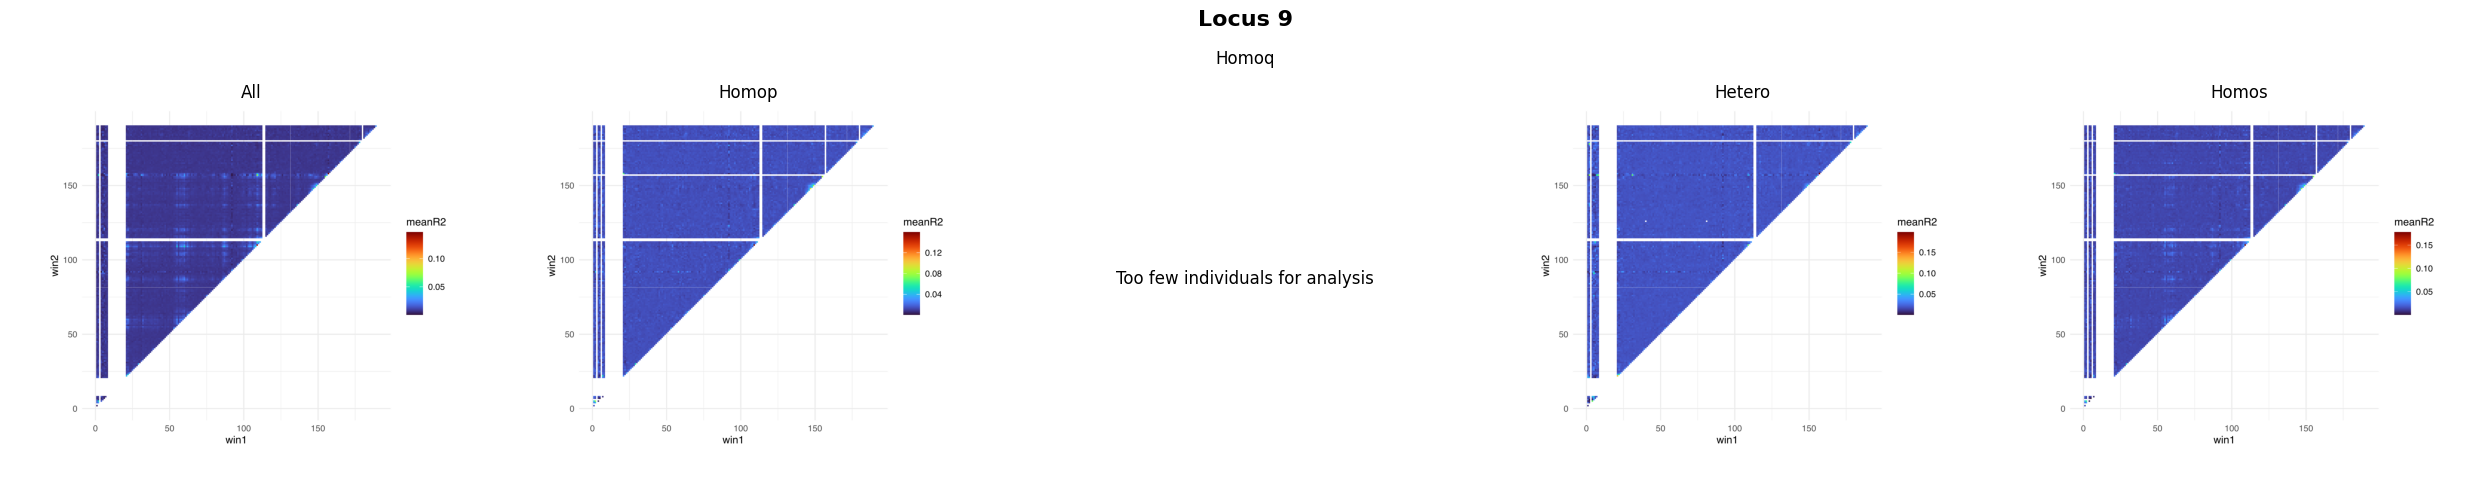

In [26]:
import os
import re
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from pdf2image import convert_from_path
import numpy as np


# Define the order of subplot types
SUBPLOT_ORDER = ['all', 'homop', 'homoq', 'hetero', 'homos']

POPPLER_PATH = "/opt/homebrew/opt/poppler/bin"

def convert_pdf_to_image(pdf_path):
    return convert_from_path(
        pdf_path,
        first_page=1,
        last_page=1,
        dpi=500,
        poppler_path=POPPLER_PATH
    )[0]

def extract_chromosome(filename):
    """Extract chromosome name (string before second underscore)."""
    match = re.match(r'([^_]+_[^_]+)', filename)
    return match.group(1) if match else None

def extract_type(filename):
    """Extract the type (all, homop, homoq, hetero, homos)."""
    for subtype in SUBPLOT_ORDER:
        if subtype in filename:
            return subtype
    return None

def read_pdfs_from_folder(folder_path):
    """Read PDF files and group by chromosome."""
    pdf_files = Path(folder_path).glob('*.pdf')
    
    # Group files by chromosome
    chromosome_files = defaultdict(dict)
    
    for pdf_file in pdf_files:
        filename = pdf_file.name
        chrom = extract_chromosome(filename)
        file_type = extract_type(filename)
        
        if chrom and file_type:
            chromosome_files[chrom][file_type] = str(pdf_file)
    
    return chromosome_files


def create_figure_for_chromosome(chrom, pdf_paths, locus_num=None):
    """Create a figure with 5 subplots for a chromosome."""
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    title = f'Locus {locus_num}' if locus_num is not None else f'Chromosome: {chrom}'
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for idx, subtype in enumerate(SUBPLOT_ORDER):
        ax = axes[idx]

        if subtype in pdf_paths:
            if 'NW_022145594.1_homoq_' in pdf_paths[subtype] or 'NW_022145609.1_homoq_' in pdf_paths[subtype] or 'NW_022145610.1_homoq_' in pdf_paths[subtype]:
                ax.text(
                    0.5,
                    0.5,
                    'Too few individuals for analysis',
                    ha='center',
                    va='center',
                    wrap=True,
                    fontsize=12,
                )
                ax.set_title(subtype.capitalize(), fontsize=12)
            else:
                try:
                    img = convert_pdf_to_image(pdf_paths[subtype])
                    if img:
                        ax.imshow(img)
                        ax.set_title(subtype.capitalize(), fontsize=12)
                    else:
                        ax.text(0.5, 0.5, f'Failed to load\n{subtype}', 
                            ha='center', va='center')
                        ax.set_title(subtype.capitalize(), fontsize=12)
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error loading\n{subtype}\n{str(e)}', 
                        ha='center', va='center')
                    ax.set_title(subtype.capitalize(), fontsize=12)
        else:
            ax.text(0.5, 0.5, f'No file for\n{subtype}', 
                   ha='center', va='center')
            ax.set_title(subtype.capitalize(), fontsize=12)
        
        ax.axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 1])
    return fig



# Path to LD plots folder
ld_plots_folder = os.path.expanduser('~/Desktop/ld_plots')

if not os.path.exists(ld_plots_folder):
    print(f"Error: Folder not found: {ld_plots_folder}")

# Read and group PDFs
chromosome_files = read_pdfs_from_folder(ld_plots_folder)

print(f"Found {len(chromosome_files)} chromosomes with PDF files")

# Sort chromosomes
sorted_chromosomes = sorted(chromosome_files.keys())
sorted_chromosomes[0], sorted_chromosomes[1] = sorted_chromosomes[1], sorted_chromosomes[0]

# Create figures
figures = []
for idx, chrom in enumerate(sorted_chromosomes, start=1):
    print(f"Creating figure for Locus {idx} ({chrom})...")
    fig = create_figure_for_chromosome(chrom, chromosome_files[chrom], locus_num=idx)
    figures.append(fig)

    

print(f"Created {len(figures)} figures")
print("Displaying plots...")

# Show all figures
plt.show()

In [19]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('ld_plots.pdf') as pdf:
    for fig in figures:
        pdf.savefig(fig)
        plt.close(fig)

In [34]:
n_loci = len(sorted_chromosomes)
fig, axes = plt.subplots(n_loci, 5, figsize=(25, 5 * n_loci), squeeze=False)


for row, chrom in enumerate(sorted_chromosomes):
    pdf_paths = chromosome_files[chrom]


    for col, subtype in enumerate(SUBPLOT_ORDER):
        ax = axes[row][col]
        if subtype in pdf_paths:
            if 'NW_022145594.1_homoq_' in pdf_paths[subtype] or 'NW_022145609.1_homoq_' in pdf_paths[subtype] or 'NW_022145610.1_homoq_' in pdf_paths[subtype]:
                ax.text(
                    0.5, 0.5,
                    'Too few individuals for analysis',
                    ha='center', va='center',
                    wrap=True, fontsize=10
                )
            else:
                try:
                    img = convert_pdf_to_image(pdf_paths[subtype])
                    if img is not None:
                        ax.imshow(img)
                except Exception as e:
                    ax.text(
                        0.5, 0.5,
                        f'Error loading\n{subtype}\n{str(e)}',
                        ha='center', va='center',
                        wrap=True, fontsize=10
                    )
        else:
            ax.text(0.5, 0.5, f'No file for\n{subtype}', ha='center', va='center')
        ax.set_title(subtype.capitalize(), fontsize=14)
        if col == 2:
            ax.text(
                0.5, 1.15,
                f'Locus {row + 1}',
                transform=ax.transAxes,
                ha='center',
                va='bottom',
                fontsize=18,
                fontweight='bold'
            )
        ax.axis('off')

#fig.suptitle('LD plots', fontsize=16, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.savefig('ld_plots_onepage.pdf', dpi=500)
plt.close(fig)